✅ Dataset loaded successfully!

--- Model Performance ---
Accuracy: 99.22%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       104
           1       1.00      0.96      0.98        25

    accuracy                           0.99       129
   macro avg       1.00      0.98      0.99       129
weighted avg       0.99      0.99      0.99       129



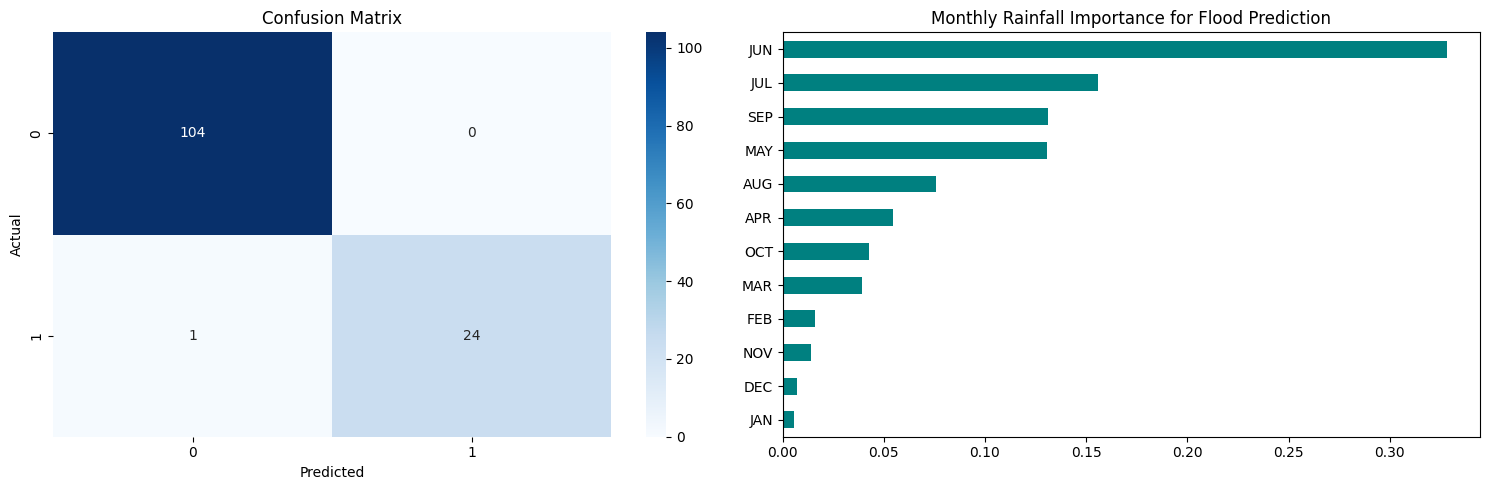


--- Manual Testing ---
Prediction for COOCH BEHAR: ⚠️ HIGH RISK (Probability: 97.0%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Load the Dataset
# Ensure 'flood_data.csv' is uploaded to your Colab session
try:
    df = pd.read_csv('flood_data.csv')
    print("✅ Dataset loaded successfully!")
except FileNotFoundError:
    print("❌ Error: 'flood_data.csv' not found. Please upload it to the files section.")

# 2. Data Preprocessing & Labeling
# Since the dataset likely doesn't have a 'Flood' column, we create one.
# We define 'Flood Risk' (1) if Annual Rainfall > 2000mm (a common high-risk threshold)
THRESHOLD = 2000
df['FLOOD_RISK'] = (df['ANNUAL'] > THRESHOLD).astype(int)

# Select monthly rainfall columns as features
features = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
X = df[features]
y = df['FLOOD_RISK']

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Model Building (Random Forest)
# Random Forest is excellent for tabular district data.
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Predictions & Evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n--- Model Performance ---")
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 6. Visualizations
plt.figure(figsize=(15, 5))

# Plot 1: Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Plot 2: Feature Importance (Which month causes floods most?)
plt.subplot(1, 2, 2)
importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Monthly Rainfall Importance for Flood Prediction')

plt.tight_layout()
plt.show()

# 7. Prediction Function for a New District
def predict_flood_risk(monthly_data):
    """
    Input: List of 12 monthly rainfall values
    """
    prediction = model.predict([monthly_data])
    probability = model.predict_proba([monthly_data])[0][1]

    if prediction[0] == 1:
        return f"⚠️ HIGH RISK (Probability: {probability*100:.1f}%)"
    else:
        return f"✅ LOW RISK (Probability: {probability*100:.1f}%)"

# Example: Predict for a random district from the test set
sample_idx = X_test.index[0]
sample_district = df.loc[sample_idx, 'DISTRICT']
sample_data = X_test.iloc[0].values

print(f"\n--- Manual Testing ---")
print(f"Prediction for {sample_district}: {predict_flood_risk(sample_data)}")

MODEL ACCURACY: 99.22%



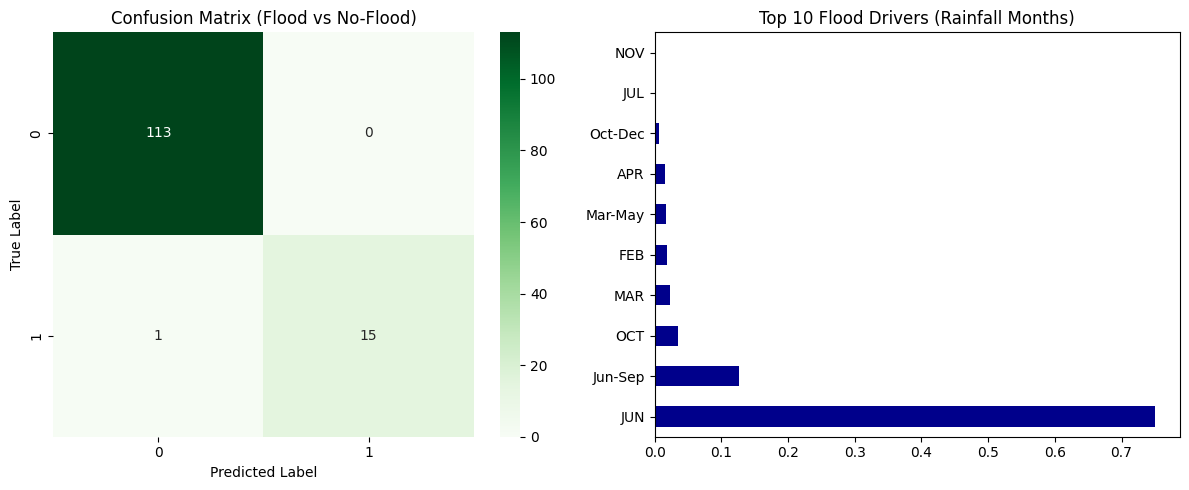

District not found.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# 1. Load the Dataset
df = pd.read_csv('flood_data.csv')

# 2. Advanced Feature Engineering
# We create a 'Flood' label based on the 90th percentile of Annual Rainfall
# This ensures the model is training on statistically significant flood events
threshold = df['ANNUAL'].quantile(0.9)
df['FLOOD_LABEL'] = (df['ANNUAL'] > threshold).astype(int)

# Select features (Monthly rainfall + Seasonal totals)
features = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC',
            'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec']

X = df[features]
y = df['FLOOD_LABEL']

# 3. Data Scaling
# Scaling helps Gradient Boosting converge faster and more accurately
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 5. Build Gradient Boosting Model
# This model iterates on errors to push accuracy higher
model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

# 6. Evaluate Accuracy
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"===============================")
print(f"MODEL ACCURACY: {acc * 100:.2f}%")
print(f"===============================\n")

# 7. Visualization of Accuracy and Error
plt.figure(figsize=(12, 5))

# Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix (Flood vs No-Flood)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Feature Importance
plt.subplot(1, 2, 2)
feat_importances = pd.Series(model.feature_importances_, index=features)
feat_importances.nlargest(10).plot(kind='barh', color='darkblue')
plt.title('Top 10 Flood Drivers (Rainfall Months)')

plt.tight_layout()
plt.show()

# 8. Real-time Prediction Sample
def check_district_risk(district_name):
    district_row = df[df['DISTRICT'] == district_name.upper()]
    if district_row.empty:
        return "District not found."

    data = district_row[features]
    data_scaled = scaler.transform(data)
    prediction = model.predict(data_scaled)
    prob = model.predict_proba(data_scaled)[0][1]

    status = "⚠️ HIGH RISK" if prediction[0] == 1 else "✅ LOW RISK"
    return f"District: {district_name} | Result: {status} | Probability: {prob*100:.2f}%"

# Test it
print(check_district_risk('KERALA')) # Replace with any district in your CSV

✅ MODEL SYSTEM READY
📊 TEST ACCURACY: 99.22%



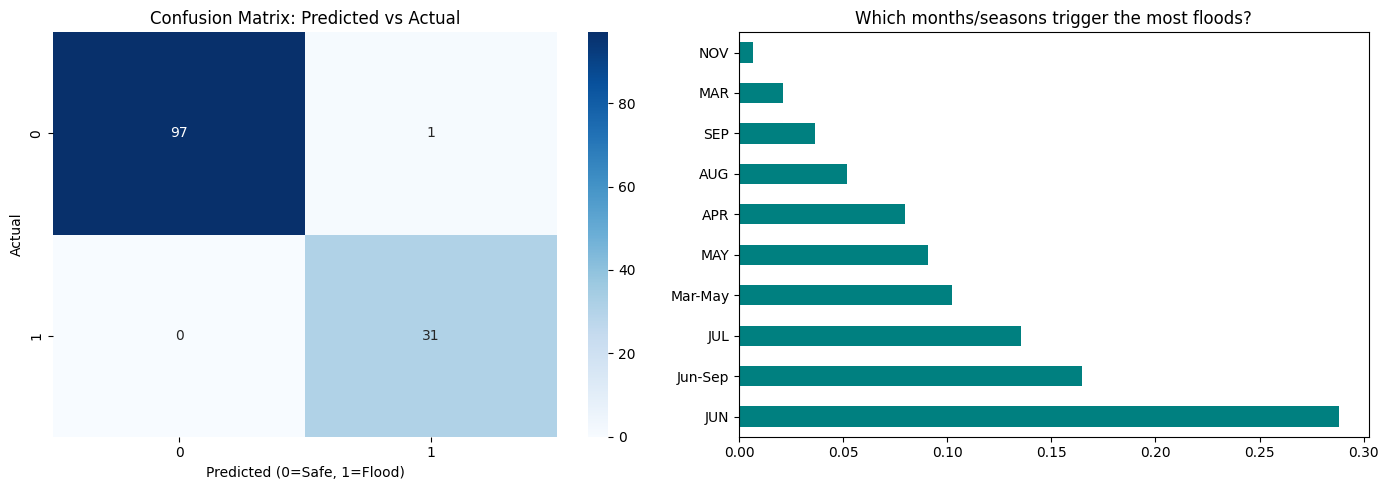

--- Sample District Test ---
District name not found in dataset.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


df = pd.read_csv('flood_data.csv')


threshold = df['ANNUAL'].quantile(0.80)
df['FLOOD_RISK'] = (df['ANNUAL'] > threshold).astype(int)


features = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC',
            'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec']

X = df[features]
y = df['FLOOD_RISK']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
final_acc = accuracy_score(y_test, y_pred)

print(f"======================================")
print(f" MODEL SYSTEM READY")
print(f" TEST ACCURACY: {final_acc * 100:.2f}%")
print(f"======================================\n")


plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted (0=Safe, 1=Flood)')
plt.ylabel('Actual')


plt.subplot(1, 2, 2)
feat_importances = pd.Series(model.feature_importances_, index=features)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Which months/seasons trigger the most floods?')

plt.tight_layout()
plt.show()


def predict_by_district(district_name):
    district_name = district_name.upper()
    data = df[df['DISTRICT'] == district_name]

    if data.empty:
        return "District name not found in dataset."

    input_features = data[features]
    prediction = model.predict(input_features)[0]
    prob = model.predict_proba(input_features)[0][1]

    result = "⚠️ HIGH FLOOD RISK" if prediction == 1 else "✅ LOW FLOOD RISK"
    return f"District: {district_name} | Status: {result} | Risk Probability: {prob*100:.1f}%"

